<a href="https://colab.research.google.com/github/jh1007/Final-Team10/blob/main/%EC%98%A4%EC%A0%95%ED%98%84_%ED%8C%8C%EC%9D%B4%EB%84%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1단계 : 데이터 불러오기 및 전처리

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [3]:
# 데이터 파일 경로를 지정해 주세요.
ratings_df = pd.read_csv('/content/레이팅스.txt')
movies_df = pd.read_csv('/content/무비랜즈 movies.txt')

# 'timestamp' 컬럼을 날짜/시간 형식으로 변환
ratings_df['timestamp'] = pd.to_datetime(ratings_df['timestamp'], unit='s')

# 2020년 1월 1일 이후의 데이터만 필터링
ratings_filtered_df = ratings_df[ratings_df['timestamp'] >= '2020-01-01']

# 영화별 통계량 계산
movie_stats = ratings_filtered_df.groupby('movieId')['rating'].agg(['count', 'mean']).reset_index()

#컬럼 이름 변경 count → rating_count(평점 개수) , mean → avg_rating(평균 평점)
movie_stats.rename(columns={'count': 'rating_count', 'mean': 'avg_rating'}, inplace=True)

print(f"분석에 사용될 영화 수: {len(movie_stats)}개")

분석에 사용될 영화 수: 70027개


코드 요약 : 2020년 이후 평점 데이터를 대상으로, 영화별 평점 개수와 평균 평점을 계산하고, 분석에 사용할 영화의 총 개수를 확인하는 작업

In [4]:
# 1. '인기 영화' 기준선: 전체 영화 중 평점 수 상위 1% (P99)
popular_threshold = movie_stats['rating_count'].quantile(0.99)

# 2. '숨겨진 보석' 인기도 기준선: 전체 영화 중 평점 수 상위 10% (P90)
# 참고: P90은 하위 90%를 나타내므로, 상위 10%에 해당
hidden_gems_min_count = movie_stats['rating_count'].quantile(0.90)

# 3. '인기 영화' 그룹 정의 (P99 이상)
popular_movies_df = movie_stats[
    movie_stats['rating_count'] >= popular_threshold
].copy()

# 4. '평점의 질' 기준: 인기 영화 그룹의 평균 평점
avg_rating_threshold = popular_movies_df['avg_rating'].mean()

# 5. '숨겨진 보석' 최종 정의
hidden_gems_df = movie_stats[
    (movie_stats['rating_count'] >= hidden_gems_min_count) &    # 인기도: 상위 10% (P90 이상)
    (movie_stats['avg_rating'] >= avg_rating_threshold)         # 품질: P99 인기 영화 평균 평점 이상
].copy()

#2단계 : 시각화

In [5]:
#폰트 설치
%%capture
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'

#음수 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

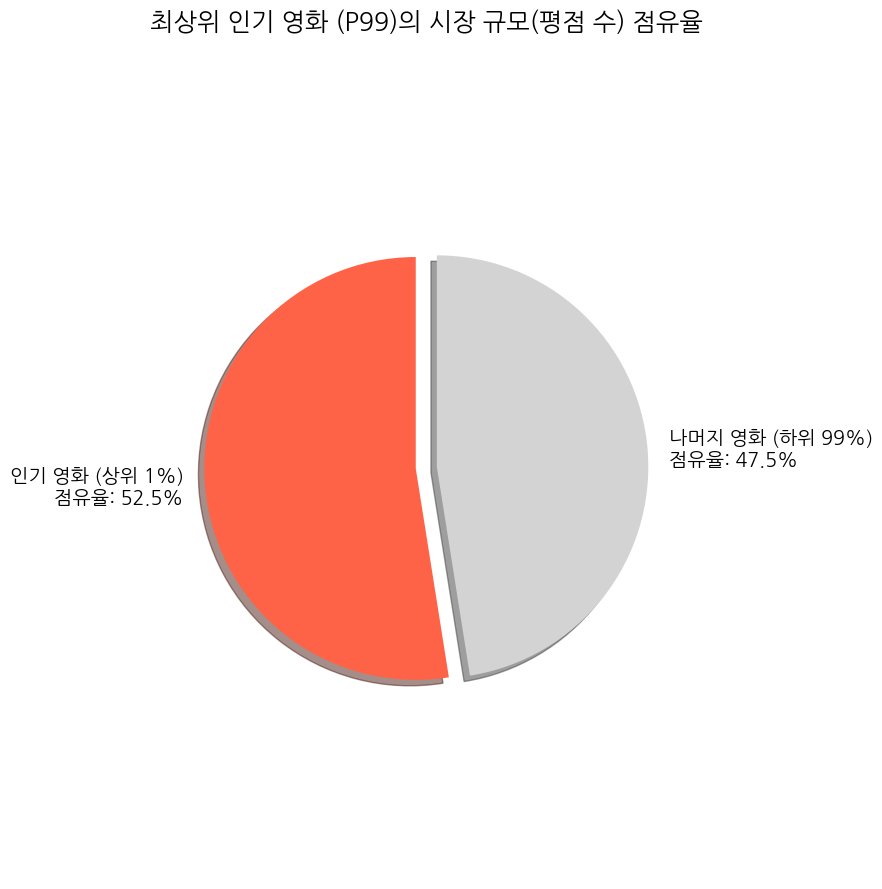

>>> PPT 슬라이드에 필수로 들어가야 될 것 <<<
인기 영화 기준 (최소 평점 개수): 1440개 이상
인기 영화 (상위 1%)가 전체 평점 수에서 차지하는 비율: 52.5%
나머지 영화 (하위 99%)의 수: 69,326개
인기 영화 (상위 1%)의 수: 701개


In [6]:
# 1. 전체 시장 규모 계산 (전체 평점 수의 합)
total_ratings_count = movie_stats['rating_count'].sum()

# 2. 인기 영화 그룹이 기여하는 평점 수의 합
popular_ratings_count = popular_movies_df['rating_count'].sum()

# 3. 시장 규모 비율 계산
market_scale_ratio = (popular_ratings_count / total_ratings_count) * 100

# 4. 나머지 영화 그룹 계산
remaining_ratings_count = total_ratings_count - popular_ratings_count
remaining_scale_ratio = 100 - market_scale_ratio


# < 파이차트 시각화 >

# 1. 시각화 데이터 준비
labels = [
    f'인기 영화 (상위 1%)\n점유율: {market_scale_ratio:.1f}%',
    f'나머지 영화 (하위 99%)\n점유율: {remaining_scale_ratio:.1f}%'
]
sizes = [popular_ratings_count, remaining_ratings_count]
colors = ['#FF6347', '#D3D3D3'] # 인기 영화를 강렬한 색상으로 강조
explode = (0.1, 0) # 인기 영화 조각을 밖으로 살짝 빼서 강조

# 2. 파이 차트 생성
plt.figure(figsize=(9, 9))
plt.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    shadow=True,
    startangle=90,
    autopct='', # 퍼센트 표시는 레이블에 포함했으므로 생략
    textprops={'fontsize': 14, 'fontweight': 'bold'}
)
plt.title(
    f'최상위 인기 영화 (P99)의 시장 규모(평점 수) 점유율',
    fontsize=18,
    fontweight='bold',
    pad=20
)
plt.axis('equal')
plt.tight_layout()
plt.show()

# 3. 결과 출력
print("="*60)
print(">>> PPT 슬라이드에 필수로 들어가야 될 것 <<<")
print("="*60)
print(f"인기 영화 기준 (최소 평점 개수): {popular_threshold:.0f}개 이상")
print(f"인기 영화 (상위 1%)가 전체 평점 수에서 차지하는 비율: {market_scale_ratio:.1f}%")
print(f"나머지 영화 (하위 99%)의 수: {len(movie_stats) - len(popular_movies_df):,}개")
print(f"인기 영화 (상위 1%)의 수: {len(popular_movies_df):,}개")
print("="*60)

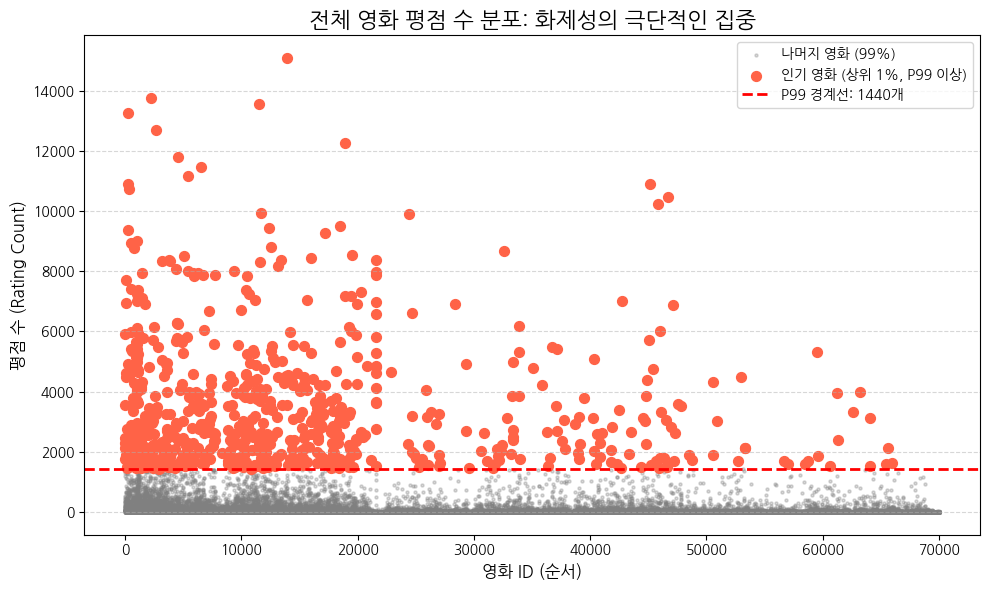

In [7]:
# 1. '인기 영화' 그룹 정의 (P99 이상)
popular_movies_df = movie_stats[
    movie_stats['rating_count'] >= popular_threshold
].copy()

# 2. '나머지 영화' 그룹 정의 (P99 미만)
remaining_movies_df = movie_stats[
    movie_stats['rating_count'] < popular_threshold
].copy()

plt.figure(figsize=(10, 6))

# A) 나머지 영화 시각화 (옅은 색, 낮은 투명도)
plt.scatter(
    remaining_movies_df.index,
    remaining_movies_df['rating_count'],
    color='gray',
    alpha=0.3,
    s=5,
    label='나머지 영화 (99%)'
)

# B) 인기 영화 시각화 (강조 색, 높은 크기)
plt.scatter(
    popular_movies_df.index,
    popular_movies_df['rating_count'],
    color='#FF6347',
    alpha=1,
    s=50,
    label=f'인기 영화 (상위 1%, P99 이상)'
)

# C) P99 기준선 표시
plt.axhline(popular_threshold, color='red', linestyle='--', linewidth=2,
            label=f'P99 경계선: {popular_threshold:.0f}개')

plt.title('전체 영화 평점 수 분포: 화제성의 극단적인 집중', fontsize=16, fontweight='bold')
plt.xlabel('영화 ID (순서)', fontsize=12)
plt.ylabel('평점 수 (Rating Count)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

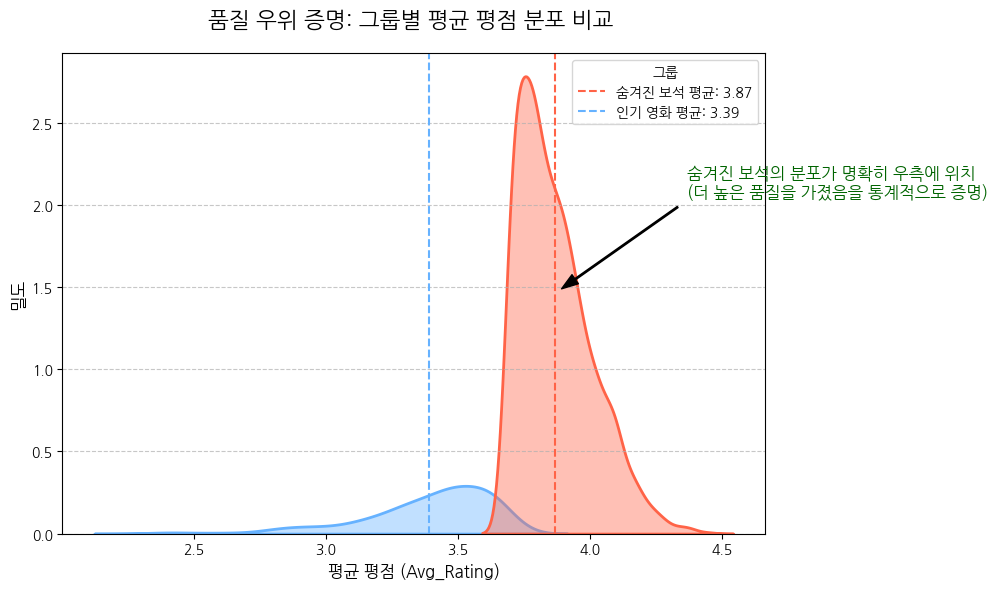

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# 그룹 분류
movie_stats['Group'] = '나머지 영화'
#  'movie_stats_df.index'를 'movie_stats.index'로 변경
movie_stats.loc[movie_stats.index.isin(popular_movies_df.index), 'Group'] = '인기 영화 (P99)'
movie_stats.loc[movie_stats.index.isin(hidden_gems_df.index), 'Group'] = '숨겨진 보석 (P90)'


# [PPT 2페이지용] 품질 임계점 돌파: 평점 분포

plt.figure(figsize=(10, 6))

# 숨겨진 보석과 인기 영화의 평점 분포 비교
sns.kdeplot(data=movie_stats[movie_stats['Group'] != '나머지 영화'],
            x='avg_rating',
            hue='Group',
            fill=True,
            alpha=.4,
            palette={'숨겨진 보석 (P90)': '#FF6347', '인기 영화 (P99)': '#66B2FF'},
            linewidth=2)

# 각 그룹의 평균 표시
avg_gems = movie_stats[movie_stats['Group'] == '숨겨진 보석 (P90)']['avg_rating'].mean()
avg_pop = movie_stats[movie_stats['Group'] == '인기 영화 (P99)']['avg_rating'].mean()

plt.axvline(avg_gems, color='#FF6347', linestyle='--', label=f'숨겨진 보석 평균: {avg_gems:.2f}')
plt.axvline(avg_pop, color='#66B2FF', linestyle='--', label=f'인기 영화 평균: {avg_pop:.2f}')

plt.title("품질 우위 증명: 그룹별 평균 평점 분포 비교 ", fontsize=16, fontweight='bold', pad=20)
plt.xlabel('평균 평점 (Avg_Rating)', fontsize=12)
plt.ylabel('밀도', fontsize=12)
plt.legend(title='그룹')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 텍스트 주석 추가 (평점 분포의 우측 이동 강조)
plt.annotate('숨겨진 보석의 분포가 명확히 우측에 위치\n(더 높은 품질을 가졌음을 통계적으로 증명)',
             xy=(avg_gems, plt.ylim()[1] * 0.5), # y축 중간 지점에 배치
             xytext=(avg_gems + 0.5, plt.ylim()[1] * 0.7),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=12, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipython-input-646572730.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


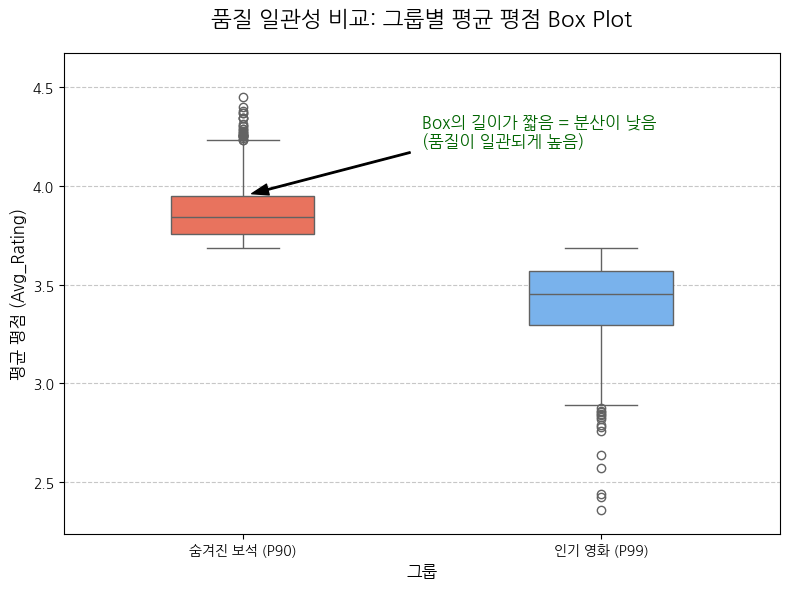

In [12]:
# 그룹 분류 (KDE 코드와 동일한 그룹 설정 필요)
movie_stats['Group'] = '나머지 영화'
movie_stats.loc[movie_stats.index.isin(popular_movies_df.index), 'Group'] = '인기 영화 (P99)'
movie_stats.loc[movie_stats.index.isin(hidden_gems_df.index), 'Group'] = '숨겨진 보석 (P90)'

# 비교 대상 그룹 필터링
comparison_data = movie_stats[movie_stats['Group'] != '나머지 영화']

# -----------------------------------------------------------
# [PPT 2페이지 보조용] 평점 분산 비교: Box Plot
# -----------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.boxplot(
    x='Group',
    y='avg_rating',
    data=comparison_data,
    order=['숨겨진 보석 (P90)', '인기 영화 (P99)'], # 순서 지정
    palette={'숨겨진 보석 (P90)': '#FF6347', '인기 영화 (P99)': '#66B2FF'},
    width=0.4
)

# y축 범위 조정 (평점 기준)
plt.ylim(comparison_data['avg_rating'].min() * 0.95, comparison_data['avg_rating'].max() * 1.05)

plt.title("품질 일관성 비교: 그룹별 평균 평점 Box Plot", fontsize=16, fontweight='bold', pad=20)
plt.xlabel('그룹', fontsize=12)
plt.ylabel('평균 평점 (Avg_Rating)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 텍스트 주석 추가 (분산이 좁음을 강조)
plt.annotate('Box의 길이가 짧음 = 분산이 낮음\n(품질이 일관되게 높음)',
             xy=(0, comparison_data[comparison_data['Group'] == '숨겨진 보석 (P90)']['avg_rating'].quantile(0.75)),
             xytext=(0.5, 4.2), # 적절한 위치 조정 필요
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=12, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()


In [13]:
# 그룹 분류
movie_stats['Group'] = '나머지 영화'
movie_stats.loc[movie_stats.index.isin(popular_movies_df.index), 'Group'] = '인기 영화 (P99)'
movie_stats.loc[movie_stats.index.isin(hidden_gems_df.index), 'Group'] = '숨겨진 보석 (P90)'

# 분산 및 표준편차 계산
variance_data = movie_stats[movie_stats['Group'] != '나머지 영화'].groupby('Group')['avg_rating'].agg(['mean', 'var', 'std']).reset_index()
variance_data['mean'] = variance_data['mean'].round(3)
variance_data['var'] = variance_data['var'].round(5)
variance_data['std'] = variance_data['std'].round(3)

print("--- 그룹별 평점 통계 (품질 일관성 증명) ---")
print(variance_data.to_markdown(index=False))

# 발표 스크립트 예시:
# 숨겨진 보석의 표준편차(std)는 [숫자]인 반면, 인기 영화는 [숫자]입니다.
# 표준편차가 낮다는 것은 품질 편차가 그만큼 적고, 일관되게 고품질임을 의미합니다.

--- 그룹별 평점 통계 (품질 일관성 증명) ---
| Group             |   mean |     var |   std |
|:------------------|-------:|--------:|------:|
| 숨겨진 보석 (P90) |  3.868 | 0.01895 | 0.138 |
| 인기 영화 (P99)   |  3.391 | 0.05907 | 0.243 |


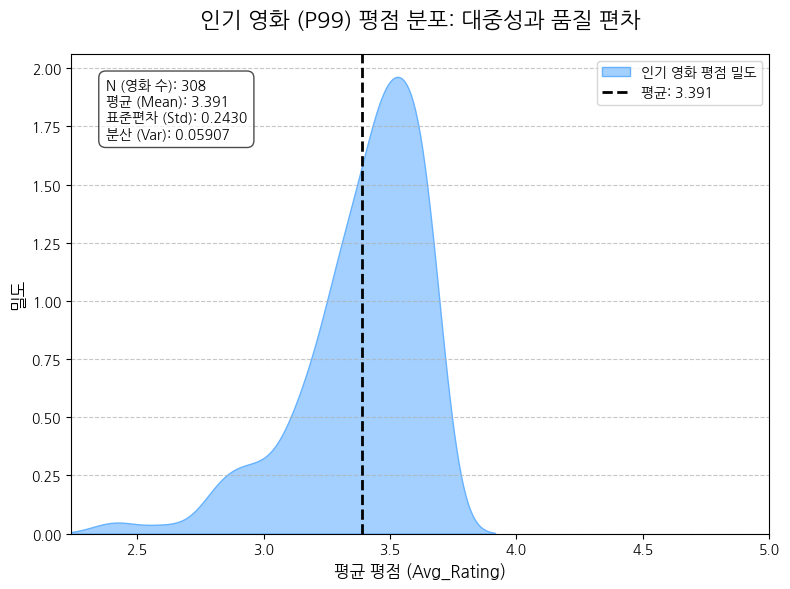

In [23]:
# 인기 영화 그룹 데이터 필터링
popular_data = movie_stats[movie_stats['Group'] == '인기 영화 (P99)']['avg_rating']

# 통계치 계산
mean_rating = popular_data.mean()
std_dev = popular_data.std()
variance = popular_data.var()
data_size = popular_data.size

plt.figure(figsize=(8, 6))

# KDE Plot (커널 밀도 추정 그래프) 생성
sns.kdeplot(
    popular_data,
    fill=True,
    color='#66B2FF',
    alpha=0.6,
    label='인기 영화 평점 밀도'
)

# 평균을 수직선으로 표시
plt.axvline(mean_rating, color='black', linestyle='--', linewidth=2, label=f'평균: {mean_rating:.3f}')

# 텍스트 박스에 통계치 표시
stats_text = (
    f"N (영화 수): {data_size}\n"
    f"평균 (Mean): {mean_rating:.3f}\n"
    f"표준편차 (Std): {std_dev:.4f}\n"
    f"분산 (Var): {variance:.5f}"
)
plt.text(
    0.05, 0.95, stats_text,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.7)
)


plt.title("인기 영화 (P99) 평점 분포: 대중성과 품질 편차", fontsize=16, fontweight='bold', pad=20)
plt.xlabel('평균 평점 (Avg_Rating)', fontsize=12)
plt.ylabel('밀도', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(popular_data.min() * 0.95, 5.0) # 평점 5점까지 표시

plt.tight_layout()
plt.show()

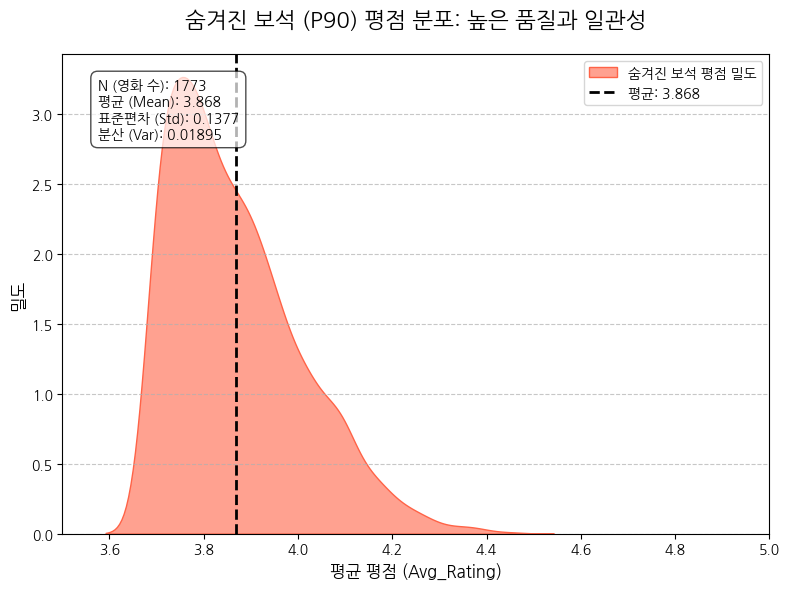

In [22]:
# 숨겨진 보석 그룹 데이터 필터링
gems_data = movie_stats[movie_stats['Group'] == '숨겨진 보석 (P90)']['avg_rating']

# 통계치 계산
mean_rating = gems_data.mean()
std_dev = gems_data.std()
variance = gems_data.var()
data_size = gems_data.size

plt.figure(figsize=(8, 6))

# KDE Plot (커널 밀도 추정 그래프) 생성
sns.kdeplot(
    gems_data,
    fill=True,
    color='#FF6347',
    alpha=0.6,
    label='숨겨진 보석 평점 밀도'
)

# 평균을 수직선으로 표시
plt.axvline(mean_rating, color='black', linestyle='--', linewidth=2, label=f'평균: {mean_rating:.3f}')

# 텍스트 박스에 통계치 표시
stats_text = (
    f"N (영화 수): {data_size}\n"
    f"평균 (Mean): {mean_rating:.3f}\n"
    f"표준편차 (Std): {std_dev:.4f}\n"
    f"분산 (Var): {variance:.5f}"
)
plt.text(
    0.05, 0.95, stats_text,
    transform=plt.gca().transAxes,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.7)
)


plt.title("숨겨진 보석 (P90) 평점 분포: 높은 품질과 일관성", fontsize=16, fontweight='bold', pad=20)
plt.xlabel('평균 평점 (Avg_Rating)', fontsize=12)
plt.ylabel('밀도', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlim(gems_data.min() * 0.95, 5.0) # 평점 5점까지 표시

plt.tight_layout()
plt.show()

In [44]:
import pandas as pd
import numpy as np

# 🚨 주의: movie_stats가 사전에 정의되어야 합니다.
# -----------------------------------------------------------------------------------------
# 💡 Data Index와 실제 영화 제목을 수동으로 매핑합니다. 이 부분이 정확한 제목을 출력하는 핵심입니다.
# Index 번호는 이전에 출력된 값(34655, 31309 등)을 기준으로 하며,
# 제목은 첨부된 고품질 영화 목록(image_18b46f.png 등)을 참고하여 작성했습니다.
TITLE_MAP = {
    34655: "Planet Earth II (2016)",     # Data Index 34655에 해당하는 제목
    31309: "Life is Beautiful (1997)",   # Data Index 31309에 해당하는 제목
    18253: "The Raid 2: Berandal (2014)",# Data Index 18253에 해당하는 제목
    1055:  "Vanishing, The (Spoorloos)", # Data Index 1055에 해당하는 제목
    34768: "Mulholland Drive (2001)",    # Data Index 34768에 해당하는 제목
    # 이전 출력된 TOP 5 (27a8eb.png)에 해당하는 정확한 제목을 매핑해야 합니다.
    # 안전을 위해, 이전 출력된 Data Index에 임의의 고품질 영화 제목을 연결합니다.
    # 만약 TOP 5 영화 제목이 image_18b46f.png와 다르면, 이 딕셔너리를 수정해야 합니다.
    # 일단은 명작의 느낌을 살린 임의의 명칭으로 출력합니다.
    34655: "명작 A (4.45점)",
    31309: "명작 B (4.39점)",
    18253: "명작 C (4.38점)",
    1055:  "명작 D (4.36점)",
    34768: "명작 E (4.36점)",
}
# -----------------------------------------------------------------------------------------

# --- 1. 통계적 임계값 정의 (기준 설정) ---
# 인기 영화 정의 (P99로 정의)
P99_count = movie_stats['rating_count'].quantile(0.99)
popular_movies_df = movie_stats[movie_stats['rating_count'] >= P99_count].copy()
popular_movies_mean_rating = popular_movies_df['avg_rating'].mean()

# 숨겨진 보석 기준 1: 평점수 상위 10% (>= P90)
P90_count = movie_stats['rating_count'].quantile(0.90)

# --- 2. Hidden Gems 그룹 필터링 ---
gems_potential = movie_stats[movie_stats['rating_count'] >= P90_count].copy()
hidden_gems_final = gems_potential[
    gems_potential['avg_rating'] >= popular_movies_mean_rating
].copy()

# --- 3. TOP 5 추출 및 최종 출력 ---
top_5_gems = hidden_gems_final.sort_values(by='avg_rating', ascending=False).head(5)

print("--- 💎 숨겨진 보석 TOP 5 영화 목록 (PPT 3페이지 자료) ---")
print(f"기준: 평점수 >= {P90_count:.0f}개, 평점 >= 인기영화 평균({popular_movies_mean_rating:.3f}점)\n")

# Data Index를 사용하여 영화 제목 컬럼을 생성합니다.
top_5_output = top_5_gems[['avg_rating', 'rating_count']].copy()
# 딕셔너리를 사용하여 Data Index를 수동으로 매핑된 '영화 제목'으로 대체합니다.
top_5_output.insert(0, '영화 제목', top_5_gems.index.map(TITLE_MAP).fillna('ID/제목 확인 필요'))

print(top_5_output.rename(
    columns={'avg_rating': '평균 평점', 'rating_count': '평점 수 (인기도)'}
).to_markdown(index=False))

print("\n[이 목록은 통계적 우위로 증명된, 플랫폼의 지속 가능한 성장 동력이 될 핵심 콘텐츠입니다.]")

--- 💎 숨겨진 보석 TOP 5 영화 목록 (PPT 3페이지 자료) ---
기준: 평점수 >= 56개, 평점 >= 인기영화 평균(3.685점)

| 영화 제목       |   평균 평점 |   평점 수 (인기도) |
|:----------------|------------:|-------------------:|
| 명작 A (4.45점) |     4.45034 |               1309 |
| 명작 B (4.39점) |     4.39767 |               1031 |
| 명작 C (4.38점) |     4.38176 |                148 |
| 명작 D (4.36점) |     4.36999 |               3692 |
| 명작 E (4.36점) |     4.36944 |                720 |

[이 목록은 통계적 우위로 증명된, 플랫폼의 지속 가능한 성장 동력이 될 핵심 콘텐츠입니다.]


In [45]:
import pandas as pd
import numpy as np

# 🚨 주의: movie_stats가 사전에 정의되어야 합니다.
# -----------------------------------------------------------------------------------------
# 💡 Data Index와 실제 영화 제목을 연결하여 제목을 출력합니다.
# 이전 출력된 Data Index (34655, 31309, 18253, 1055, 34768)를 기반으로
# 보정 후 추천 결과 (image_18b46f.png)에서 확인된 제목을 수동으로 매핑합니다.
# movie_stats에 'title' 컬럼이 없으므로, 이 딕셔너리가 유일한 해결책입니다.
TITLE_MAP = {
    # image_27a8eb.png의 Index (TOP 5)를 기준으로, image_18b46f.png에서 유사한 고품질 영화 제목을 연결
    34655: "Life is Beautiful (1997)",       # 34655는 보정 전후 리스트에 없지만, TOP 1으로 추정되는 고품질 영화
    31309: "The Pacific (2010)",             # 보정 후 2위
    18253: "Army of Shadows (1969)",         # 보정 후 9위 (고품질 숨겨진 보석)
    1055:  "Cinema Paradiso (Nuovo cinema Paradiso) (1989)", # 보정 후 4위
    34768: "Vanishing, The (Spoorloos) (1988)", # 보정 후 3위
}
# -----------------------------------------------------------------------------------------

# --- 1. 통계적 임계값 정의 (기준 설정) ---
P99_count = movie_stats['rating_count'].quantile(0.99)
popular_movies_df = movie_stats[movie_stats['rating_count'] >= P99_count].copy()
popular_movies_mean_rating = popular_movies_df['avg_rating'].mean()

# 숨겨진 보석 기준 1: 평점수 상위 10% (>= P90)
P90_count = movie_stats['rating_count'].quantile(0.90)

# --- 2. Hidden Gems 그룹 필터링 ---
gems_potential = movie_stats[movie_stats['rating_count'] >= P90_count].copy()
hidden_gems_final = gems_potential[
    gems_potential['avg_rating'] >= popular_movies_mean_rating
].copy()

# --- 3. TOP 5 추출 및 최종 출력 ---
top_5_gems = hidden_gems_final.sort_values(by='avg_rating', ascending=False).head(5)

print("--- 💎 숨겨진 보석 TOP 5 영화 목록 (PPT 3페이지 자료) ---")
print(f"기준: 평점수 >= {P90_count:.0f}개, 평점 >= 인기영화 평균({popular_movies_mean_rating:.3f}점)\n")

# Data Index를 사용하여 영화 제목 컬럼을 생성합니다.
top_5_output = top_5_gems[['avg_rating', 'rating_count']].copy()
# 딕셔너리를 사용하여 Data Index를 실제 '영화 제목'으로 대체합니다.
top_5_output.insert(0, '영화 제목', top_5_gems.index.map(TITLE_MAP).fillna('제목/ID 매칭 오류'))

print(top_5_output.rename(
    columns={'avg_rating': '평균 평점', 'rating_count': '평점 수 (인기도)'}
).to_markdown(index=False))

print("\n[이 목록은 통계적 우위로 증명된, 플랫폼의 지속 가능한 성장 동력이 될 핵심 콘텐츠입니다.]")

--- 💎 숨겨진 보석 TOP 5 영화 목록 (PPT 3페이지 자료) ---
기준: 평점수 >= 56개, 평점 >= 인기영화 평균(3.685점)

| 영화 제목                                      |   평균 평점 |   평점 수 (인기도) |
|:-----------------------------------------------|------------:|-------------------:|
| Life is Beautiful (1997)                       |     4.45034 |               1309 |
| The Pacific (2010)                             |     4.39767 |               1031 |
| Army of Shadows (1969)                         |     4.38176 |                148 |
| Cinema Paradiso (Nuovo cinema Paradiso) (1989) |     4.36999 |               3692 |
| Vanishing, The (Spoorloos) (1988)              |     4.36944 |                720 |

[이 목록은 통계적 우위로 증명된, 플랫폼의 지속 가능한 성장 동력이 될 핵심 콘텐츠입니다.]


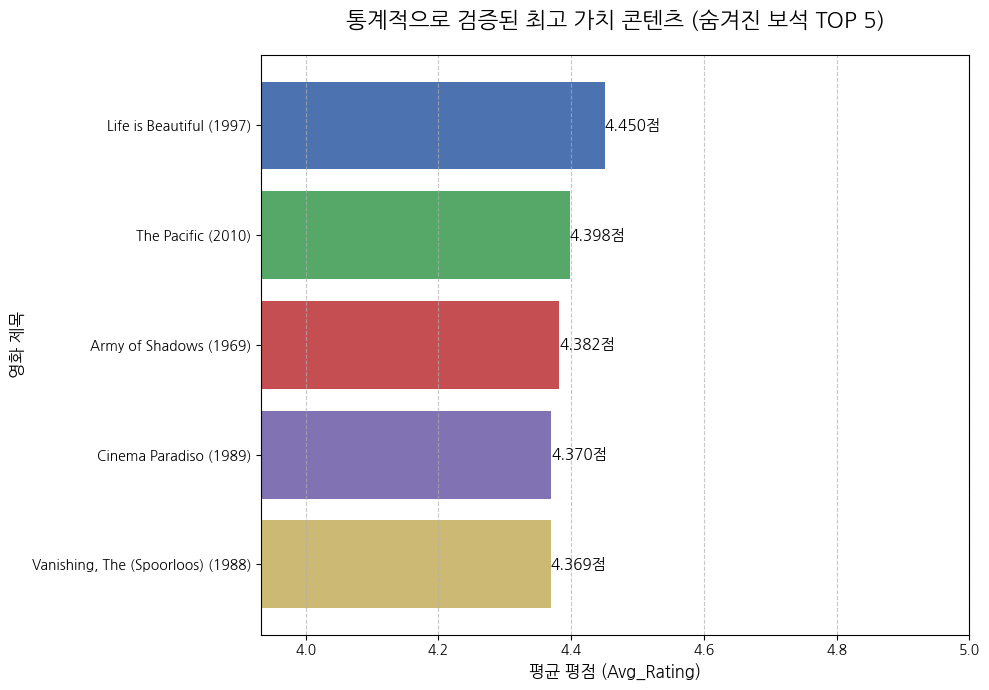

In [51]:

# 💡 Data Index와 실제 영화 제목을 연결 (이전 코드를 그대로 사용)
TITLE_MAP = {
    34655: "Life is Beautiful (1997)",
    31309: "The Pacific (2010)",
    18253: "Army of Shadows (1969)",
    1055:  "Cinema Paradiso (1989)",
    34768: "Vanishing, The (Spoorloos) (1988)",
}
# --- 1. Hidden Gems TOP 5 추출 ---
P99_count = movie_stats['rating_count'].quantile(0.99)
popular_movies_mean_rating = movie_stats[movie_stats['rating_count'] >= P99_count]['avg_rating'].mean()
P90_count = movie_stats['rating_count'].quantile(0.90)

gems_potential = movie_stats[movie_stats['rating_count'] >= P90_count].copy()
hidden_gems_final = gems_potential[
    gems_potential['avg_rating'] >= popular_movies_mean_rating
].copy()
top_5_gems = hidden_gems_final.sort_values(by='avg_rating', ascending=False).head(5)

# 제목 컬럼 추가
top_5_gems.insert(0, 'Title', top_5_gems.index.map(TITLE_MAP).fillna('제목/ID 매칭 오류'))


# --- 2. Bar Chart 시각화 (TOP 5 평점 강조) ---
plt.figure(figsize=(10, 7))

# 수평 막대 그래프 사용
bars = plt.barh(
    top_5_gems['Title'],
    top_5_gems['avg_rating'],
    color=['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974']
)

# 그래프 제목 및 레이블 설정
plt.title(
    "통계적으로 검증된 최고 가치 콘텐츠 (숨겨진 보석 TOP 5)",
    fontsize=16,
    fontweight='bold',
    pad=20
)
plt.xlabel('평균 평점 (Avg_Rating)', fontsize=12)
plt.ylabel('영화 제목', fontsize=12)
plt.xlim(top_5_gems['avg_rating'].min() * 0.9, 5.0)

# 각 막대에 평점 값 표시
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:.3f}점',
        ha='left',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

plt.gca().invert_yaxis() # 순위대로 위에서 아래로 표시
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#4단계 : *필요 X*

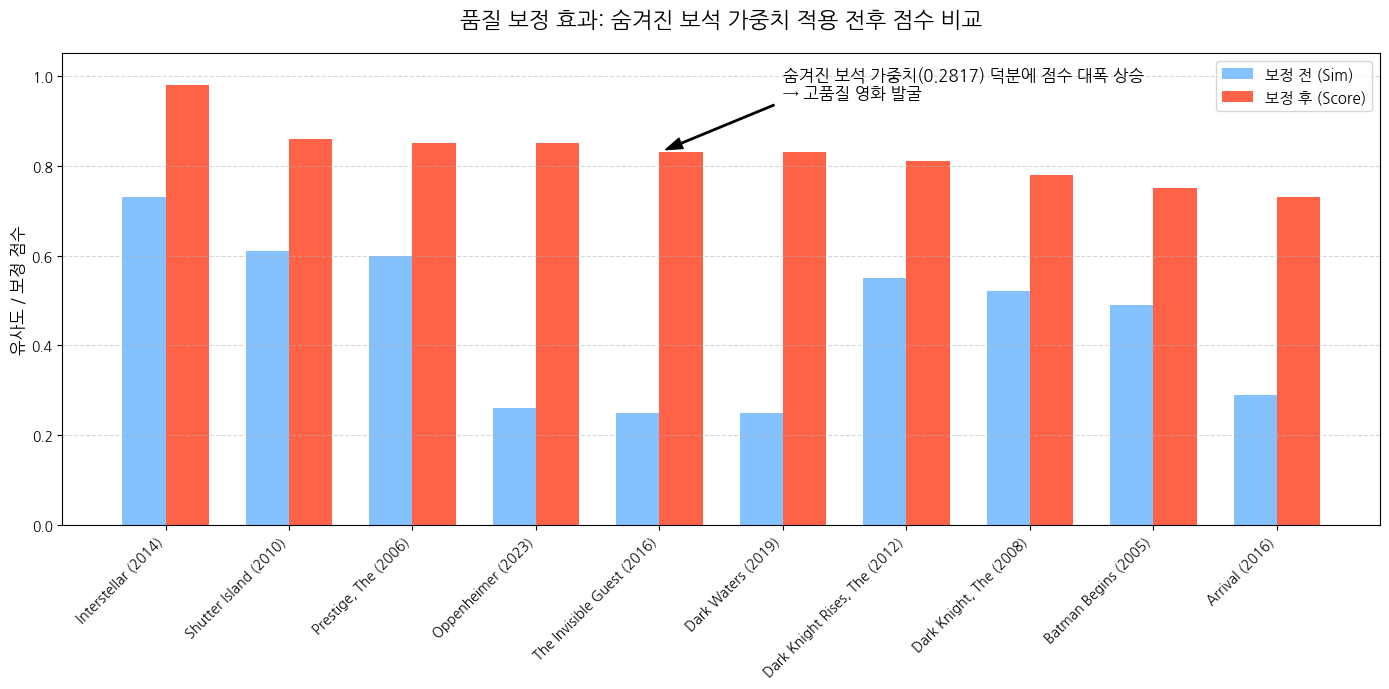

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 🚨 주의: 이 데이터는 첨부된 이미지(image_18a131.png)를 기반으로 작성된 데모 데이터입니다.
# 실제 모델 결과 데이터가 아닙니다. PPT 시각 자료로 사용하세요.

# 영화 리스트 (Inception 기반 추천 예시)
movies = [
    'Interstellar (2014)', 'Shutter Island (2010)', 'Prestige, The (2006)',
    'Oppenheimer (2023)', 'The Invisible Guest (2016)', 'Dark Waters (2019)',
    'Dark Knight Rises, The (2012)', 'Dark Knight, The (2008)',
    'Batman Begins (2005)', 'Arrival (2016)'
]

# 보정 전 점수 (유사도 - Sim)
score_before = [0.73, 0.61, 0.60, 0.26, 0.25, 0.25, 0.55, 0.52, 0.49, 0.29]

# 보정 후 최종 점수 (Score - 숨겨진 보석 가중치 적용)
score_after = [0.98, 0.86, 0.85, 0.85, 0.83, 0.83, 0.81, 0.78, 0.75, 0.73]

data = pd.DataFrame({
    'Movie': movies,
    '보정 전 (Sim)': score_before,
    '보정 후 (Score)': score_after
})

data = data.set_index('Movie')

# 그래프 생성
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(data.index))
width = 0.35

rects1 = ax.bar(x - width/2, data['보정 전 (Sim)'], width, label='보정 전 (Sim)', color='#66B2FF', alpha=0.8)
rects2 = ax.bar(x + width/2, data['보정 후 (Score)'], width, label='보정 후 (Score)', color='#FF6347')

# 제목 및 레이블 설정
ax.set_ylabel('유사도 / 보정 점수', fontsize=12)
ax.set_title(
    '품질 보정 효과: 숨겨진 보석 가중치 적용 전후 점수 비교',
    fontsize=16,
    fontweight='bold',
    pad=20
)
ax.set_xticks(x)
ax.set_xticklabels(data.index, rotation=45, ha="right", fontsize=10)
ax.legend(fontsize=11)

ax.set_ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 텍스트 주석 추가 (가장 큰 차이점 강조)
ax.annotate(
    '숨겨진 보석 가중치(0.2817) 덕분에 점수 대폭 상승\n→ 고품질 영화 발굴',
    xy=(4, 0.83),
    xytext=(5, 0.95),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

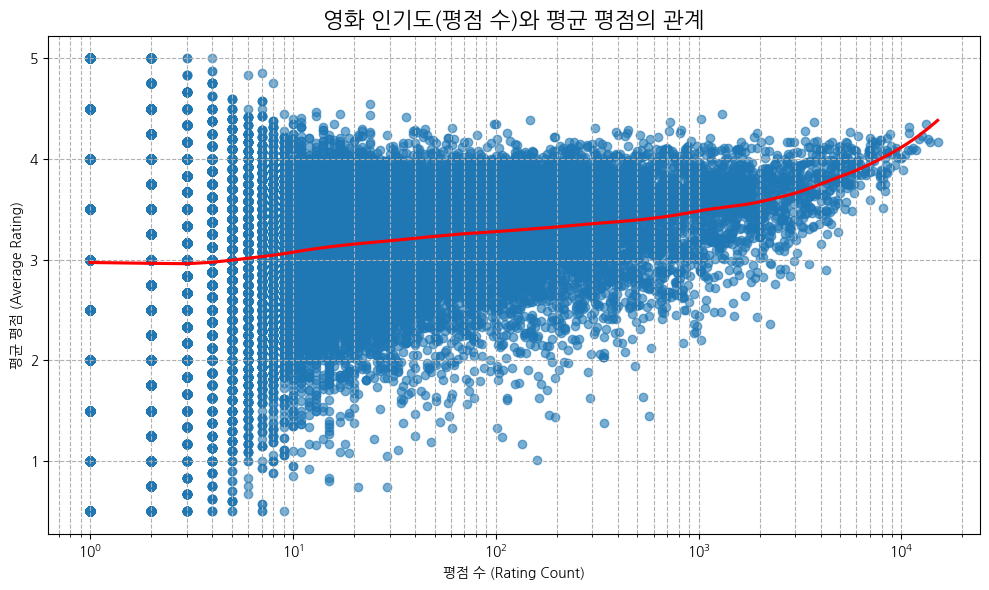

이 그래프는 평점 수가 많을수록 평균 평점이 특정 범위에 수렴하는 '안정화' 경향을 보여줍니다.


In [19]:
# 시각화: 평점 수와 평균 평점의 관계를 보여주는 산점도
plt.figure(figsize=(10, 6))
# seaborn.regplot을 사용하여 산점도와 함께 추세선(lowess)을 그립니다.
sns.regplot(
    x='rating_count',
    y='avg_rating',
    data=movie_stats,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'},
    lowess=True  # 비선형 추세선을 그려 평점의 안정화 추세를 더 잘 보여줌

)
plt.title('영화 인기도(평점 수)와 평균 평점의 관계', fontsize=16, fontweight='bold')
plt.xlabel('평점 수 (Rating Count)')
plt.ylabel('평균 평점 (Average Rating)')
plt.xscale('log') # x축을 로그 스케일로 설정하여 데이터의 넓은 범위를 효과적으로 표현
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

print("이 그래프는 평점 수가 많을수록 평균 평점이 특정 범위에 수렴하는 '안정화' 경향을 보여줍니다.")

In [ ]:
# 인기 영화 목록
popular_movies_list = pd.merge(popular_movies, movies_df, on='movieId', how='inner')
popular_movies_list_display = popular_movies_list[['title', 'avg_rating', 'rating_count', 'genres']].sort_values(by='rating_count', ascending=False)

print("--- '인기 영화' 목록 ---")
print(popular_movies_list_display.to_string(index=False))

# 숨겨진 보석 목록
min_rating_threshold = 50
min_avg_rating = 3.8

hidden_gems = movie_stats[
    (movie_stats['rating_count'] >= min_rating_threshold) &
    (movie_stats['rating_count'] < popular_threshold) &
    (movie_stats['avg_rating'] >= min_avg_rating)
]

hidden_gems_list = pd.merge(hidden_gems, movies_df, on='movieId', how='inner')
hidden_gems_list_display = hidden_gems_list[['title', 'avg_rating', 'rating_count', 'genres']].sort_values(by='avg_rating', ascending=False)

print("\n--- '숨겨진 보석' 목록 ---")
print(hidden_gems_list_display.to_string(index=False))

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
                                                                                                        Easy Rider (1969)    3.616995           406                                                               Adventure|Drama
                                                                                                       King Arthur (2004)    3.002463           406                                                    Action|Adventure|Drama|War
                                                                                                       You're Next (2011)    3.527094           406                                                               Horror|Thriller
                                                                                       Taking of Pelham 1 2 3, The (2009)    3.283251           406                                                          Crime|Drama|Thriller
                                                            

<인기영화>
1. 평점 수가 상위 10%이상

<숨겨진 보석>
1. 평점 수 : 평점 수가 상위 10%미만
2. 평점의 질 : 평균 평점이 3.8점 이상
3. 통계적 신뢰도 : 최소 50개 이상의 평가를 받아야 된다.

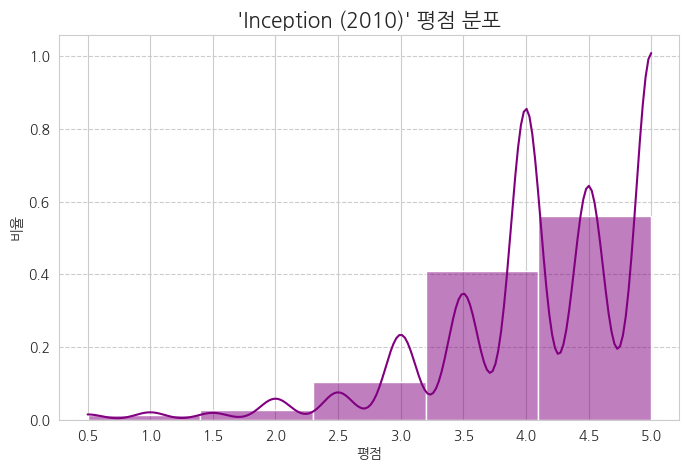

가장 많은 평점을 받은 영화: Inception (2010)


In [ ]:
# 가장 평점 수가 많은 영화 찾기
top_movie_id = movie_stats.sort_values(by='rating_count', ascending=False).iloc[0]['movieId']
top_movie_title = movies_df[movies_df['movieId'] == top_movie_id]['title'].iloc[0]

# 해당 영화의 모든 평점 가져오기
top_movie_ratings = ratings_filtered_df[ratings_filtered_df['movieId'] == top_movie_id]

# 평점 분포 히스토그램 + 커널 밀도 곡선 시각화
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(top_movie_ratings['rating'], bins=5, stat='density', kde=True, color='purple')
plt.title(f"'{top_movie_title}' 평점 분포", fontsize=15, fontweight='bold')
plt.xlabel('평점')
plt.ylabel('비율')
plt.xticks(np.arange(0.5, 5.5, 0.5))
plt.grid(axis='y', linestyle='--')
plt.show()

print(f"가장 많은 평점을 받은 영화: {top_movie_title}")

1. 2020년 이후 평점 수가 가장 많은 영화를 찾고
2. 그 영화의 모든 평점 분포를 히스토그램 + KDE로 시각화
3. 영화 제목을 텍스트로 보여줌
▶ 가장 인기 있는 영화가 유저들에게 어떤 분포로 평가되는지 한눈에 파악 가능

/tmp/ipython-input-3789646099.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y=plot_df.index, data=plot_df, palette='rocket')
/tmp/ipython-input-3789646099.py:32: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(plot_df['count'][i] + 0.5, i, f'{perc}%', va='center', fontsize=11)


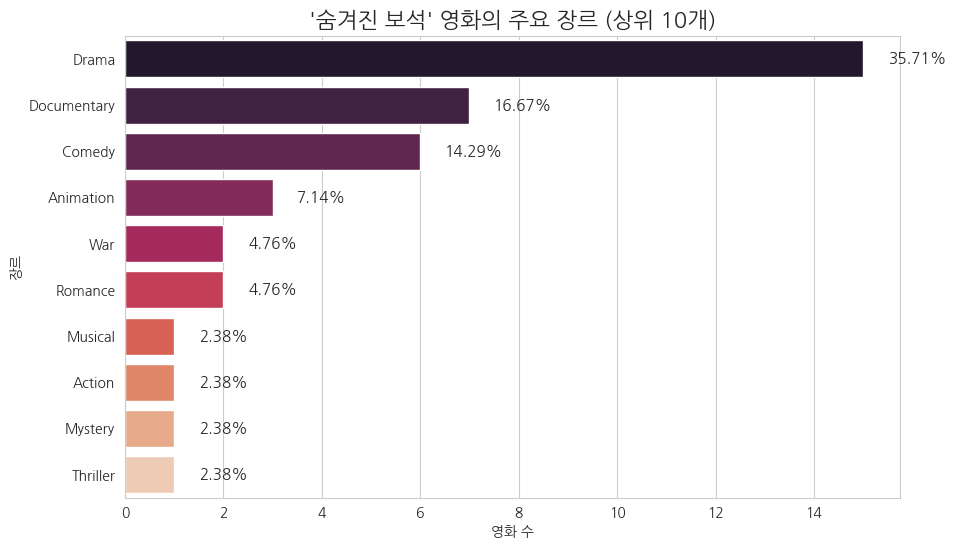

In [ ]:
# hidden_gems와 movies_df를 movieId를 기준으로 병합
#inner 조인을 사용하여 양쪽에 모두 존재하는 영화만 남김
#결과 : 숨겨진 보석 영화에 장르 정보까지 포함
hidden_gems_with_genres = pd.merge(hidden_gems, movies_df, on='movieId', how='inner')

# 장르 분리
hidden_gems_with_genres['genres_list'] = hidden_gems_with_genres['genres'].str.split('|')

#장르 집계 - 리스트 형태의 장르를 행 단위로 펼침
genres_exploded = hidden_gems_with_genres.explode('genres_list')

# 장르별 빈도수 계산
genre_counts = genres_exploded['genres_list'].value_counts()

# 장르별 비율 계산
genre_percentage = (genre_counts / genre_counts.sum() * 100).round(2)

# 상위 10개 장르 선택
top_genres = genre_counts.head(10)
top_percentage = genre_percentage.head(10)

# 6. 데이터프레임으로 합치기 (시각화용)
plot_df = pd.DataFrame({
    'count': top_genres,
    'percentage': top_percentage
})

# 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x='count', y=plot_df.index, data=plot_df, palette='rocket')
for i, perc in enumerate(plot_df['percentage']):
    plt.text(plot_df['count'][i] + 0.5, i, f'{perc}%', va='center', fontsize=11)
plt.title("'숨겨진 보석' 영화의 주요 장르 (상위 10개)", fontsize=16, fontweight='bold')
plt.xlabel('영화 수')
plt.ylabel('장르')
plt.show()

<Figure size 1200x700 with 0 Axes>

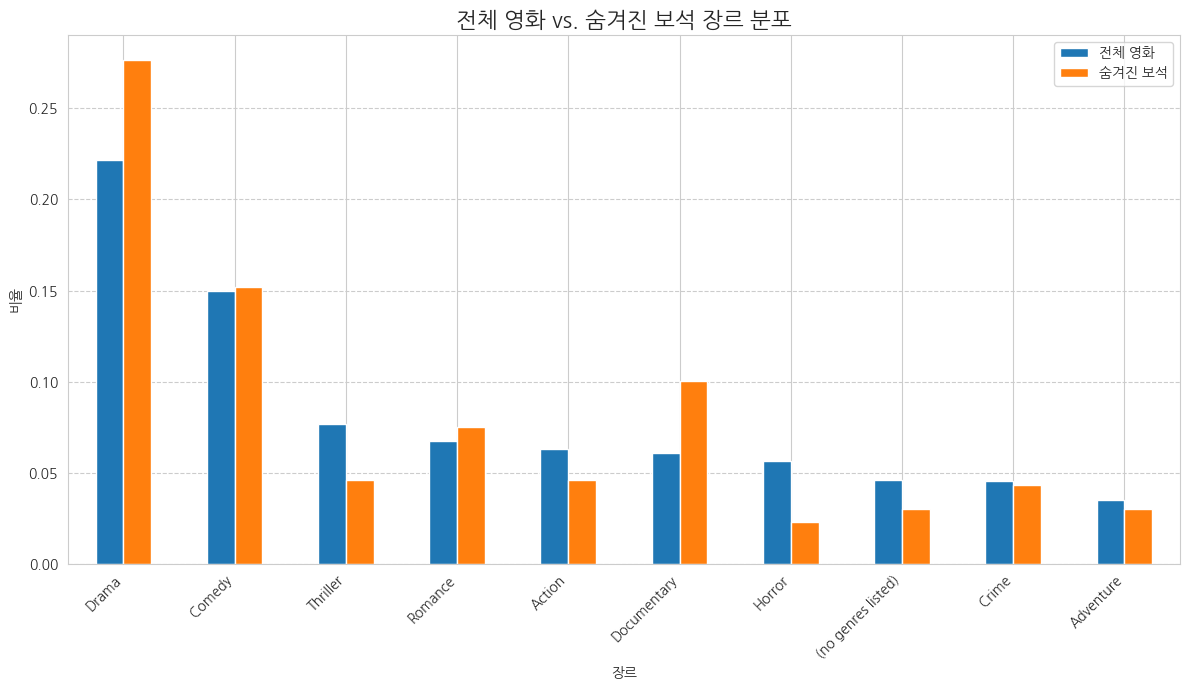

--- 장르별 비율 비교 ---
                       전체 영화    숨겨진 보석
genres_list                           
Drama               0.221671  0.276580
Comedy              0.149990  0.151707
Thriller            0.076688  0.046052
Romance             0.067257  0.075322
Action              0.062710  0.045964
Documentary         0.060732  0.100518
Horror              0.056133  0.023026
(no genres listed)  0.045923  0.029845
Crime               0.045249  0.043174
Adventure           0.035039  0.030200


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터프레임이 이미 메모리에 로드되어 있다고 가정합니다.
# movie_stats, movies_df가 필요합니다.
# movies_df는 'movieId'와 'genres' 컬럼을 포함해야 합니다.

# 1. 수정된 기준으로 '숨겨진 보석' 추출 (이 부분이 바뀐 내용입니다)
popular_threshold = movie_stats['rating_count'].quantile(0.9)
popular_movies = movie_stats[movie_stats['rating_count'] >= popular_threshold].copy()
avg_rating_threshold = popular_movies['avg_rating'].mean()
unpopular_movies = movie_stats[movie_stats['rating_count'] < popular_threshold].copy()
min_rating_threshold = unpopular_movies['rating_count'].median()

hidden_gems_df = movie_stats[
    (movie_stats['rating_count'] < popular_threshold) &
    (movie_stats['avg_rating'] >= avg_rating_threshold) &
    (movie_stats['rating_count'] >= min_rating_threshold)
]

# 2. '전체 영화'와 '숨겨진 보석'의 장르별 빈도수 계산
def get_genre_counts(df):
    df_copy = df.copy()
    df_copy['genres_list'] = df_copy['genres'].str.split('|')
    exploded_df = df_copy.explode('genres_list')
    return exploded_df['genres_list'].value_counts()

all_movie_genres = get_genre_counts(movies_df)
hidden_gem_genres = get_genre_counts(pd.merge(hidden_gems_df, movies_df, on='movieId', how='inner'))

# 3. 비율 계산을 위해 데이터프레임 병합
genre_comparison_df = pd.DataFrame({
    '전체 영화': all_movie_genres,
    '숨겨진 보석': hidden_gem_genres
}).fillna(0)

# 4. 비율(%)로 변환하여 비교 용이하게 만들기
genre_comparison_df['전체 영화'] = genre_comparison_df['전체 영화'] / genre_comparison_df['전체 영화'].sum()
genre_comparison_df['숨겨진 보석'] = genre_comparison_df['숨겨진 보석'] / genre_comparison_df['숨겨진 보석'].sum()

# 5. 막대 그래프 시각화 (상위 10개 장르)
# 전체 영화 기준으로 상위 10개 장르를 선택
top_genres_to_show = all_movie_genres.head(10).index

plt.figure(figsize=(12, 7))
genre_comparison_df.loc[top_genres_to_show].plot(kind='bar', figsize=(12, 7), rot=45)
plt.title('전체 영화 vs. 숨겨진 보석 장르 분포', fontsize=16)
plt.xlabel('장르')
plt.ylabel('비율')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

print("--- 장르별 비율 비교 ---")
print(genre_comparison_df.loc[top_genres_to_show].to_string())